In [ ]:
%pip install -U langchain langchain-openai
!apt-get install -y graphviz graphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libgraphviz-dev' instead of 'graphviz-dev'
graphviz is already the newest version (2.42.2-6ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


# 第一个 LangGraph 应用

## Hello World 示例

你好，张三！ 👋


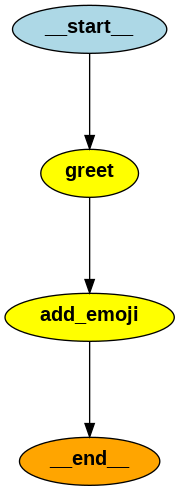

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# 1. 定义 State
class HelloState(TypedDict):
    name: str
    greeting: str

# 2. 定义节点
def greet(state: HelloState) -> dict:
    name = state["name"]
    return {"greeting": f"你好，{name}！"}

def add_emoji(state: HelloState) -> dict:
    greeting = state["greeting"]
    return {"greeting": greeting + " 👋"}

# 3. 构建图
graph = StateGraph(HelloState)

graph.add_node("greet", greet)
graph.add_node("add_emoji", add_emoji)

graph.add_edge(START, "greet")
graph.add_edge("greet", "add_emoji")
graph.add_edge("add_emoji", END)

# 4. 编译
app = graph.compile()

# 5. 运行
result = app.invoke({"name": "张三"})
print(result["greeting"])  # 输出：你好，张三！ 👋
from IPython.display import Image, display

# 使用 Graphviz 渲染（Colab 最稳定的方案）
try:
    display(Image(app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(app.get_graph(xray=True).draw_mermaid())

## 条件分支示例

温度：25°C
建议：穿短袖，记得防晒！


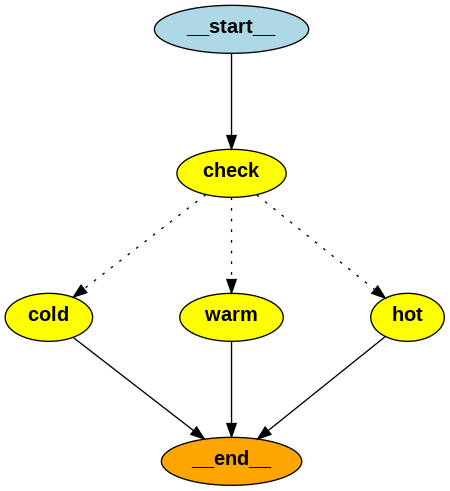

In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

class WeatherState(TypedDict):
    temperature: int
    recommendation: str

def check_temperature(state: WeatherState) -> dict:
    # 这里可以调用真实的天气 API
    return {"temperature": 25}

def route_by_temperature(state: WeatherState) -> Literal["cold", "warm", "hot"]:
    """根据温度路由"""
    temp = state["temperature"]
    if temp < 15:
        return "cold"
    elif temp < 25:
        return "warm"
    else:
        return "hot"

def recommend_cold(state: WeatherState) -> dict:
    return {"recommendation": "穿厚外套！"}

def recommend_warm(state: WeatherState) -> dict:
    return {"recommendation": "穿长袖就好。"}

def recommend_hot(state: WeatherState) -> dict:
    return {"recommendation": "穿短袖，记得防晒！"}

# 构建图
graph = StateGraph(WeatherState)

graph.add_node("check", check_temperature)
graph.add_node("cold", recommend_cold)
graph.add_node("warm", recommend_warm)
graph.add_node("hot", recommend_hot)

graph.add_edge(START, "check")
graph.add_conditional_edges(
    "check",
    route_by_temperature,
    {
        "cold": "cold",
        "warm": "warm",
        "hot": "hot"
    }
)

for node in ["cold", "warm", "hot"]:
    graph.add_edge(node, END)

app = graph.compile()

# 测试
result = app.invoke({})
print(f"温度：{result['temperature']}°C")
print(f"建议：{result['recommendation']}")
from IPython.display import Image, display

# 使用 Graphviz 渲染（Colab 最稳定的方案）
try:
    display(Image(app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(app.get_graph(xray=True).draw_mermaid())

# 实战项目：Workflow vs Agent 对比

## 方案一：Workflow 实现

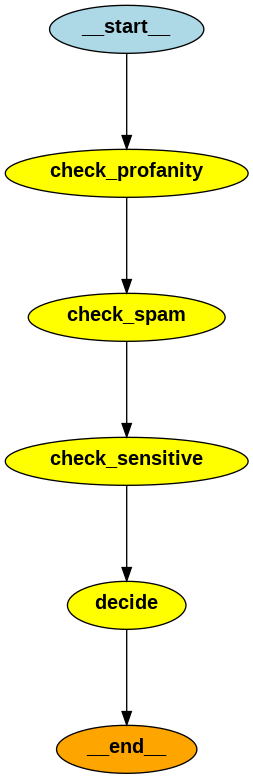

In [ ]:
import re
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# === State 定义 ===
class ContentModerationState(TypedDict):
    content: str
    has_profanity: bool
    has_spam_pattern: bool
    has_sensitive_topics: bool
    decision: str  # "approved" | "rejected" | "needs_review"
    reason: str

# === 节点实现 ===

def check_profanity(state: ContentModerationState) -> dict:
    """检查脏话（规则基于）"""
    content = state["content"].lower()
    profanity_list = ["脏话1", "脏话2", "敏感词"]  # 实际应用中从数据库加载

    has_profanity = any(word in content for word in profanity_list)
    return {"has_profanity": has_profanity}

def check_spam(state: ContentModerationState) -> dict:
    """检查垃圾信息模式"""
    content = state["content"]

    # 规则1：重复字符
    has_repeat = bool(re.search(r'(.)\1{5,}', content))

    # 规则2：过多链接
    has_many_links = content.count("http") > 3

    # 规则3：全大写
    has_all_caps = content.isupper() and len(content) > 20

    has_spam = has_repeat or has_many_links or has_all_caps
    return {"has_spam_pattern": has_spam}

def check_sensitive_topics(state: ContentModerationState) -> dict:
    """检查敏感话题"""
    content = state["content"].lower()
    sensitive_keywords = ["政治", "暴力", "色情"]  # 简化示例

    has_sensitive = any(keyword in content for keyword in sensitive_keywords)
    return {"has_sensitive_topics": has_sensitive}

def make_decision(state: ContentModerationState) -> dict:
    """综合决策"""
    has_profanity = state.get("has_profanity", False)
    has_spam = state.get("has_spam_pattern", False)
    has_sensitive = state.get("has_sensitive_topics", False)

    if has_profanity:
        return {
            "decision": "rejected",
            "reason": "包含不当语言"
        }
    elif has_sensitive:
        return {
            "decision": "needs_review",
            "reason": "包含敏感话题，需人工审核"
        }
    elif has_spam:
        return {
            "decision": "rejected",
            "reason": "疑似垃圾信息"
        }
    else:
        return {
            "decision": "approved",
            "reason": "内容正常"
        }

# === 构建 Workflow ===
workflow_graph = StateGraph(ContentModerationState)

# 添加节点
workflow_graph.add_node("check_profanity", check_profanity)
workflow_graph.add_node("check_spam", check_spam)
workflow_graph.add_node("check_sensitive", check_sensitive_topics)
workflow_graph.add_node("decide", make_decision)

# 固定的执行顺序
workflow_graph.add_edge(START, "check_profanity")
workflow_graph.add_edge("check_profanity", "check_spam")
workflow_graph.add_edge("check_spam", "check_sensitive")
workflow_graph.add_edge("check_sensitive", "decide")
workflow_graph.add_edge("decide", END)

# 编译
workflow_app = workflow_graph.compile()


from IPython.display import Image, display
try:
    display(Image(workflow_app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(app.get_graph(xray=True).draw_mermaid())


In [ ]:
# === 测试 ===
test_contents = [
    "这是一条正常的评论。",
    "这包含脏话1的内容",
    "AAAAAAAAAAAAAAAAAAA买买买！！！",
    "讨论政治话题的内容"
]

print("=== Workflow 实现结果 ===\n")
for content in test_contents:
    result = workflow_app.invoke({"content": content})
    print(f"内容：{content}")
    print(f"决策：{result['decision']}")
    print(f"原因：{result['reason']}\n")

=== Workflow 实现结果 ===

内容：这是一条正常的评论。
决策：approved
原因：内容正常

内容：这包含脏话1的内容
决策：rejected
原因：包含不当语言

内容：AAAAAAAAAAAAAAAAAAA买买买！！！
决策：rejected
原因：疑似垃圾信息

内容：讨论政治话题的内容
决策：needs_review
原因：包含敏感话题，需人工审核



## 方案二：Agent 实现

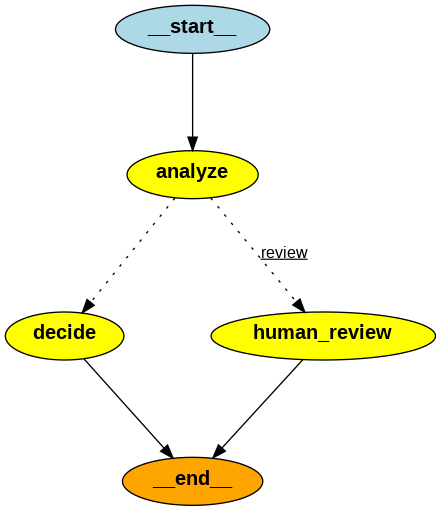

In [ ]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from langchain.messages import SystemMessage, HumanMessage

# === State 定义 ===
class AgentModerationState(TypedDict):
    content: str
    analysis: str
    decision: str  # "approved" | "rejected" | "needs_review"
    reason: str
    confidence: float
from google.colab import userdata
API_KEY = userdata.get('SILICONFLOW_API_KEY')
# === LLM 初始化 ===
model = init_chat_model(
    "Qwen/Qwen3-8B",
    model_provider="openai",
    base_url="https://api.siliconflow.cn/v1",
    api_key= API_KEY,
    temperature=0.0
)
# === 节点实现 ===

def analyze_content(state: AgentModerationState) -> dict:
    """使用 LLM 分析内容"""
    content = state["content"]

    system_prompt = """你是一个内容审核助手。分析给定的内容，判断是否包含：
    1. 不当语言（脏话、侮辱）
    2. 垃圾信息（广告、刷屏）
    3. 敏感话题（政治、暴力、色情）

    请以 JSON 格式返回：
    {
        "has_issues": true/false,
        "issues": ["issue1", "issue2"],
        "severity": "low/medium/high",
        "confidence": 0.0-1.0
    }
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"内容：{content}")
    ]

    response = model.invoke(messages)
    return {"analysis": response.content}

def make_agent_decision(state: AgentModerationState) -> dict:
    """基于 LLM 分析做决策"""
    analysis = state["analysis"]
    content = state["content"]

    system_prompt = """基于之前的分析结果，做出审核决策：
    - approved: 内容正常，通过
    - rejected: 明显违规，直接拒绝
    - needs_review: 需要人工审核

    返回 JSON 格式：
    {
        "decision": "approved/rejected/needs_review",
        "reason": "简短说明",
        "confidence": 0.0-1.0
    }
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"原内容：{content}\n\n分析结果：{analysis}")
    ]

    response = model.invoke(messages)

    # 简化处理：直接解析响应（实际应用中应该用 JSON mode）
    import json
    try:
        result = json.loads(response.content)
        return {
            "decision": result["decision"],
            "reason": result["reason"],
            "confidence": result["confidence"]
        }
    except:
        # 解析失败，保守决策
        return {
            "decision": "needs_review",
            "reason": "分析结果解析失败",
            "confidence": 0.0
        }

# === 路由函数 ===
def should_auto_decide(state: AgentModerationState) -> Literal["decide", "review"]:
    """根据分析结果决定是否需要人工"""
    # 这里可以添加更复杂的逻辑
    # 例如：如果分析中提到高风险，直接转人工
    if "high" in state.get("analysis", "").lower():
        return "review"
    return "decide"

def human_review_placeholder(state: AgentModerationState) -> dict:
    """人工审核占位符（实际应用中会中断等待人工）"""
    return {
        "decision": "needs_review",
        "reason": "已转人工审核",
        "confidence": 1.0
    }

# === 构建 Agent Graph ===
agent_graph = StateGraph(AgentModerationState)

agent_graph.add_node("analyze", analyze_content)
agent_graph.add_node("decide", make_agent_decision)
agent_graph.add_node("human_review", human_review_placeholder)

agent_graph.add_edge(START, "analyze")
agent_graph.add_conditional_edges(
    "analyze",
    should_auto_decide,
    {
        "decide": "decide",
        "review": "human_review"
    }
)
agent_graph.add_edge("decide", END)
agent_graph.add_edge("human_review", END)

agent_app = agent_graph.compile()


from IPython.display import Image, display
try:
    display(Image(agent_app.get_graph(xray=True).draw_png()))
except Exception as e:
    print(f"Graphviz 渲染失败: {e}")
    print("\n使用 Mermaid 文本方式显示:")
    print(app.get_graph(xray=True).draw_mermaid())


In [ ]:


# === 测试 ===
print("\n=== Agent 实现结果 ===\n")
for content in test_contents:
    result = agent_app.invoke({"content": content})
    print(f"内容：{content}")
    print(f"分析：{result.get('analysis', 'N/A')[:100]}...")
    print(f"决策：{result['decision']}")
    print(f"原因：{result['reason']}")
    print(f"置信度：{result.get('confidence', 'N/A')}\n")


=== Agent 实现结果 ===

内容：这是一条正常的评论。
分析：{
    "has_issues": false,
    "issues": [],
    "severity": "low",
    "confidence": 1.0
}...
决策：approved
原因：内容正常，无违规迹象
置信度：1.0

内容：这包含脏话1的内容
分析：{
    "has_issues": true,
    "issues": ["不当语言"],
    "severity": "high",
    "confidence": 0.95
}...
决策：needs_review
原因：已转人工审核
置信度：1.0

内容：AAAAAAAAAAAAAAAAAAA买买买！！！
分析：{
    "has_issues": false,
    "issues": [],
    "severity": "low",
    "confidence": 0.8
}...
决策：approved
原因：内容无明显违规，为正常表达情绪的购物行为
置信度：0.8

内容：讨论政治话题的内容
分析：{
    "has_issues": true,
    "issues": ["敏感话题"],
    "severity": "high",
    "confidence": 0.95
}...
决策：needs_review
原因：已转人工审核
置信度：1.0



# **混合方案（推荐）：**

In [ ]:
# 第一层：Workflow 快速过滤明显违规
# 第二层：Agent 处理边缘情况

def hybrid_approach(content: str):
    # 1. 先用 Workflow 快速检查
    workflow_result = workflow_app.invoke({"content": content})

    # 2. 如果 Workflow 决策明确（approved 或 rejected），直接返回
    if workflow_result["decision"] in ["approved", "rejected"]:
        return workflow_result

    # 3. 否则，使用 Agent 做深度分析
    agent_result = agent_app.invoke({"content": content})
    return agent_result